In [ ]:
import os
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

data_folder = '../data/'
path = os.path.join(data_folder)

df = pd.DataFrame()
df2 = pd.DataFrame()
for file in os.listdir(path):
    if 'price_history_full' in file:
        df = pd.read_csv(data_folder + file)
        

launch_path = '../data/official_launch_prices.csv' #added on 26.05
launch_ref = pd.read_csv(launch_path)


df = df.merge(launch_ref, on = 'submodel_name')
df['official_premiere_date'] = pd.to_datetime(df['official_premiere_date'])


df['datetime'] = pd.to_datetime(df['datetime'])
df['days_since_launch'] = (df['datetime'] - df['official_premiere_date']).dt.days
df = df[df['days_since_launch'] > 0]

df['NEW'] = df['new_price'] * 100 #required multiplication as Keepa API stores the prices divided by 100 for some reason
df = df.drop('new_price', axis = 1)

df['price_pct_of_launch'] = round(df['NEW'] / df['official_launch_price'] * 100, 1)
df['days_rounded'] = (df['days_since_launch'] / 7).round() * 7


<StringArray>
[]
Length: 0, dtype: str


In [ ]:

#Monthly Sales - Chart 3 - Sales Rank vs Generations (iPhone 13, 14, 15 etc.) + days from premiere
#Created on 25.05, updated on 26.05 to account for THE ACTUAL OFFICIAL PREMIERE DATES (mean of all memory size prices) and launch prices for each submodel
ms_df = pd.read_csv('../data/monthly_sold_full.csv')
ms_df = ms_df.merge(launch_ref, on = 'submodel_name', how = 'left')

ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])

del(ms_df['premiere_date']) #deleting it so it doesn't confuse us later - the official premiere date is what matters

ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]

ms_df['tier'] = ms_df.apply(
    lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(),
    axis=1
)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')


filtered_df = ms_df[(ms_df['tier'] == 'Base') & (ms_df['brand'] == 'Apple') & (ms_df['monthly_sold'] >= 0)]
filtered_df = filtered_df.groupby(['generation_name', 'days_rounded'])['monthly_sold'].agg('mean').reset_index()
ms_chart_3 = px.line(
    filtered_df,
    x = 'days_rounded',
    y = 'monthly_sold',
    color = 'generation_name',
    title = 'Sales Rank over time - base iPhones across generations (higher = more sold)'
)
ms_chart_3.update_yaxes(autorange='reversed', title_text = 'Monthly sales rank')
ms_chart_3.update_xaxes(title_text = 'Days since launch')
ms_chart_3.show()


In [29]:
#Chart 4 - Sales Rank vs Submodels of a given generation (iPhone 13 Base vs Pro vs Pro Max vs Mini etc.) + days from premiere

filtered_df = ms_df[ms_df['generation_name'] == 'iPhone 13']
filtered_df = filtered_df.groupby(['submodel_name', 'days_rounded'])['monthly_sold'].agg('mean').reset_index()

ms_chart_4 = px.line(
    filtered_df,
    x = 'days_rounded',
    y = 'monthly_sold',
    color = 'submodel_name',
    title = 'Sales Rank over time - iPhone 13 submodels (lower rank = more sold)'
)
ms_chart_4.update_yaxes(autorange='reversed', title_text = 'Monthly sales rank')
ms_chart_4.update_xaxes(title_text = 'Days since launch')
ms_chart_4.show()


In [32]:
#Chart 5 - Sales Rank vs Generations (iPhone 13, 14, 15 etc.) + actual datetimes

ms_df = pd.read_csv('../data/monthly_sold_full.csv')

ms_df = ms_df.merge(launch_ref, on = 'submodel_name', how = 'left')

ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])

del(ms_df['premiere_date']) #deleting it so it doesn't confuse us later - the official premiere date is what matters

ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]

ms_df['tier'] = ms_df.apply(
    lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(),
    axis=1
)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')




filtered_df = ms_df[(ms_df['tier'] == 'Base') & (ms_df['brand'] == 'Apple') & (ms_df['monthly_sold'] >= 0)]
filtered_df = (filtered_df
    .set_index('datetime')
    .groupby('generation_name')
    .resample('W')['monthly_sold']
    .mean()
    .reset_index()
)
filtered_df['monthly_sold'] = filtered_df.groupby('generation_name')['monthly_sold'].ffill()


filtered_df.head()
ms_chart_5 = px.line(
    filtered_df,
    x = 'datetime',
    y = 'monthly_sold',
    color = 'generation_name',
    title = 'Sales Rank over time - base iPhones across generations (higher = more sold)'
)
ms_chart_5.update_yaxes(autorange='reversed', title_text = 'Monthly sales rank')
ms_chart_5.update_xaxes(title_text = 'Date')

for year in range(2022, 2025):
    ms_chart_5.add_vline(x=int(pd.Timestamp(f'{year}-09-15').timestamp() * 1000), line_dash='dot', line_color='gray', annotation_text='Launch')
    ms_chart_5.add_vline(x=int(pd.Timestamp(f'{year}-11-25').timestamp() * 1000), line_dash='dot', line_color='orange', annotation_text='BF')
    ms_chart_5.add_vline(x=int(pd.Timestamp(f'{year}-12-20').timestamp() * 1000), line_dash='dot', line_color='red', annotation_text='Xmas')


ms_chart_5.show()

In [50]:
#Chart 6 - Sales Rank vs Submodels (iPhone 13 Base vs Pro vs Pro Max etc) + actual datetimes

ms_df = pd.read_csv('../data/monthly_sold_full.csv')

ms_df = ms_df.merge(launch_ref, on = 'submodel_name', how = 'left')


ms_df['official_premiere_date'] = pd.to_datetime(ms_df['official_premiere_date'])
ms_df['datetime'] = pd.to_datetime(ms_df['datetime'])

del(ms_df['premiere_date']) #deleting it so it doesn't confuse us later - the official premiere date is what matters

ms_df['days_since_launch'] = (ms_df['datetime'] - ms_df['official_premiere_date']).dt.days
ms_df['days_rounded'] = (ms_df['days_since_launch'] / 7).round() * 7
ms_df = ms_df[ms_df['days_since_launch'] >= 0]

ms_df['tier'] = ms_df.apply(
    lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(),
    axis=1
)
ms_df['tier'] = ms_df['tier'].replace('', 'Base')


filtered_df = ms_df[(ms_df['brand'] == 'Apple') & (ms_df['monthly_sold'] >= 0) & (ms_df['generation_name'] == 'iPhone 13')]
filtered_df = (filtered_df
    .set_index('datetime')
    .groupby('submodel_name')
    .resample('W')['monthly_sold']
    .mean()
    .reset_index()
)
filtered_df['monthly_sold'] = filtered_df.groupby('submodel_name')['monthly_sold'].ffill()


filtered_df.head()
ms_chart_6 = px.line(
    filtered_df,
    x = 'datetime',
    y = 'monthly_sold',
    color = 'submodel_name',
    title = 'Sales Rank over time - iPhone 13 submodels (higher = more sold)'
)
ms_chart_6.update_yaxes(autorange='reversed', title_text = 'Monthly sales rank')
ms_chart_6.update_xaxes(title_text = 'Date')
for year in range(2022, 2026):
    ms_chart_6.add_vline(x=int(pd.Timestamp(f'{year}-09-15').timestamp() * 1000),
        line_dash='dot', line_color='gray',
        annotation_text='Launch', annotation_position='top right')
    ms_chart_6.add_vline(x=int(pd.Timestamp(f'{year}-11-25').timestamp() * 1000),
        line_dash='dot', line_color='orange',
        annotation_text='BF', annotation_position='bottom right')
    ms_chart_6.add_vline(x=int(pd.Timestamp(f'{year}-12-20').timestamp() * 1000),
        line_dash='dot', line_color='red',
        annotation_text='Xmas', annotation_position='top left')


ms_chart_6.show()

I think Vlines are necessary, but we need to name them properly so they're visible.
Beyond that, this data is really bad as it starts late 2023, so we can't really see the patterns in a proper way.

In [61]:

'''Price Decay Chart 1
Price decay with relative days_rounded values.
I also need  to check Samsung/Pixel (there are different values there)
'''
df['tier'] = df.apply(
    lambda row: row['submodel_name'].replace(row['generation_name'], '').strip(),
    axis=1
)
df['tier'] = df['tier'].replace('', 'Base')



#Apple df filtering - 1
base_apple_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Apple') & (df['generation_name'] != 'iPhone 17')] #also filtered out iPhone 17 due to weird spikes - it's the latest one and perhaps there's not enough data yet or it's not properly structured in Keepa API 
grouped_base_apple_df = base_apple_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].agg('mean').reset_index()
grade_means = df[
    (df['tier'] == 'Base') & (df['brand'] == 'Apple')
].groupby('product_grade')['price_pct_of_launch'].mean()

renewed_premium_premium = grade_means['Renewed Premium'] - grade_means['Renewed'] #iPhone diff between Renewed vs Renewed Premium product grades

#Samsung df filtering - 1b
base_samsung_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Samsung')]
grouped_base_samsung_df = base_samsung_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].agg('mean').reset_index()
grade_means = df[
    (df['tier'] == 'Base') & (df['brand'] == 'Samsung')
].groupby('product_grade')['price_pct_of_launch'].mean()


#Google df filtering - 1c
base_google_df = df[(df['tier'] == 'Base') & (df['brand'] == 'Google')] #also filtered out iPhone 17 due to weird spikes - it's the latest one and perhaps there's not enough data yet or it's not properly structured in Keepa API 
grouped_base_google_df = base_google_df.groupby(['generation_name', 'product_grade', 'days_rounded'])['price_pct_of_launch'].agg('mean').reset_index()
grade_means = df[
    (df['tier'] == 'Base') & (df['brand'] == 'Google')
].groupby('product_grade')['price_pct_of_launch'].mean()


#All brands combined
base_combined_df = df[(df['tier'] == 'Base')]
grouped_base_combined_df = base_combined_df.groupby(['brand', 'days_rounded'])['price_pct_of_launch'].agg('mean').reset_index()
grade_means = df[
    (df['tier'] == 'Base')
].groupby('brand')['price_pct_of_launch'].mean()


#Apple chart - 1
pd_chart_1 = px.line(
    grouped_base_apple_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch', 
    color = 'generation_name',
    line_dash = 'product_grade',
    title = 'Price decay across base iPhone models'
)
pd_chart_1.update_yaxes(title_text = 'Price as % of the launch price')
pd_chart_1.update_xaxes(title_text = 'Days since launch')
pd_chart_1.add_hline(y = 50)
pd_chart_1.show()


#Samsung chart - 1b
pd_chart_1b = px.line(
    grouped_base_samsung_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch', 
    color = 'generation_name', #Product grade distinction was pointless here as there were almost only New phones sold (with one exception of S20 Renewed Premium)
    title = 'Price decay across base Samsung models'
)
pd_chart_1b.update_yaxes(title_text = 'Price as % of the launch price')
pd_chart_1b.update_xaxes(title_text = 'Days since launch')
pd_chart_1b.add_hline(y = 50)
pd_chart_1b.show()


#Google chart - 1c
pd_chart_1c = px.line(
    grouped_base_google_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch', 
    color = 'generation_name',
    title = 'Price decay across base Google models'
)
pd_chart_1c.update_yaxes(title_text = 'Price as % of the launch price')
pd_chart_1c.update_xaxes(title_text = 'Days since launch')
pd_chart_1c.add_hline(y = 50)
pd_chart_1c.show()


#Combined brands chart - 1d
pd_chart_1d = px.line(
    grouped_base_combined_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch', 
    color = 'brand',
    title = 'Price decay across all base models'
)
pd_chart_1d.update_yaxes(title_text = 'Price as % of the launch price')
pd_chart_1d.update_xaxes(title_text = 'Days since launch')
pd_chart_1d.add_hline(y = 50)
pd_chart_1d.show()

In [42]:
'''Price Decay Chart 2 - price decay by submodels - here for iPhone13

I'd like to make it interactive and switchable for all models
'''

generation_df = df[df['generation_name'] == 'iPhone 13']
grouped_generation_decay_df = generation_df.groupby(['submodel_name', 'days_rounded'])['price_pct_of_launch'].agg('mean').reset_index()

pd_chart_2 = px.line(
    grouped_generation_decay_df,
    x = 'days_rounded',
    y = 'price_pct_of_launch',
    color = 'submodel_name',
    title = 'Price decay - Iphone 13 by submodels'
)
pd_chart_2.add_hline(y = 50)
pd_chart_2.update_yaxes(title_text = 'Price as % of the launch price')
pd_chart_2.update_xaxes(title_text = 'Days since launch')
pd_chart_2.show()

3 (78, 23)


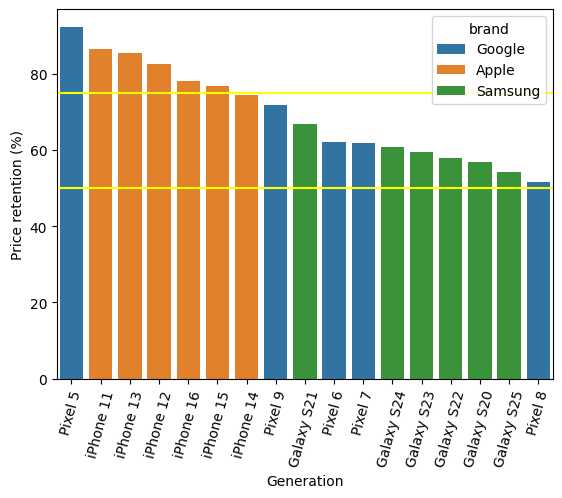

In [64]:
#Price Decay Chart 7 - Brand comparison at FULL YEAR

'''Pixel 5 sus'''

yearly_change_df = df[(df['days_rounded'] > 330) & (df['days_rounded'] < 380)]

grouped_df = yearly_change_df.groupby('generation_name').agg(
   price_retention = ('price_pct_of_launch', 'mean'),
   brand = ('brand', 'first')
).reset_index()
grouped_df = grouped_df.sort_values(by = 'price_retention', ascending = False)

print(yearly_change_df[yearly_change_df['generation_name'] == 'Pixel 5']['asin'].nunique(),
yearly_change_df[yearly_change_df['generation_name'] == 'Pixel 5'].shape)


apple_retention = grouped_df.groupby('brand')['price_retention'].agg(
   'mean').reset_index().head(1).values.tolist()[0][1]
google_retention = grouped_df.groupby('brand')['price_retention'].agg(
   'mean').reset_index().head(2).values.tolist()[1][1]
samsung_retention = grouped_df.groupby('brand')['price_retention'].agg(
   'mean').reset_index().head(3).values.tolist()[2][1]

pd_chart_7 = sns.barplot(
   data = grouped_df,
   x = 'generation_name',
   y = 'price_retention',
   hue = 'brand'
)

plt.axhline(75, color = 'yellow')
plt.axhline(50, color = 'yellow')
plt.xlabel('Generation')
plt.ylabel('Price retention (%)')
plt.xticks(rotation = 75)
plt.show()


Without surprise it seems like iPhones retain their vcalue the most. Pixel 5 is the clear winner here, but I guess the data might be sparse or there can be another reason, because other Pixels are not performing that well. 

It would be nice to also do a check of value counts and maybe also add a boxplot to check how things look like.





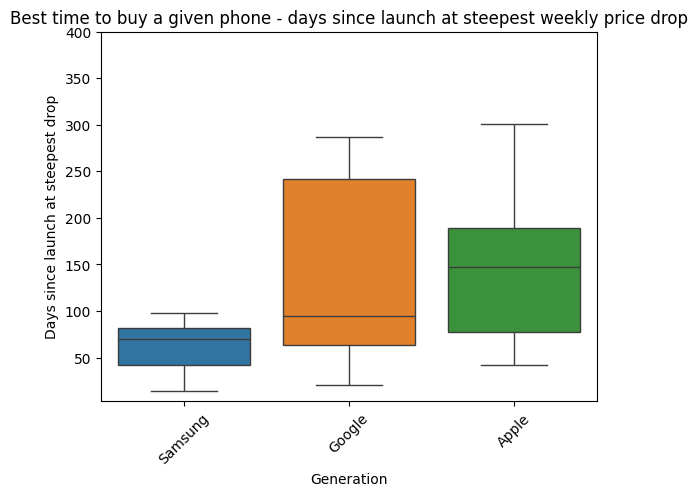

In [63]:
''' '''


df['weekly_price_diff'] = df.groupby('asin')['NEW'].diff()
df['weekly_price_diff'] = df['weekly_price_diff'].fillna(0)

grouped_df = df.groupby(['generation_name', 'days_rounded'])['weekly_price_diff'].agg('mean').reset_index()
best_time_to_buy = grouped_df.loc[grouped_df.groupby('generation_name')['weekly_price_diff'].idxmin()]

brand_lookup = df[['generation_name', 'brand']].drop_duplicates()
best_time_to_buy = best_time_to_buy.merge(brand_lookup, how = 'left', on = 'generation_name')

pd_chart_8 = sns.boxplot(
    best_time_to_buy,
    x = 'brand',
    y = 'days_rounded',
    hue = 'brand'
)
pd_chart_8.set_title('Best time to buy a given phone - days since launch at steepest weekly price drop')
plt.xlabel('Generation')
plt.ylabel('Days since launch at steepest drop')
plt.xticks(rotation = 45)
plt.ylim(3, 400)
plt.show()



I'm not sure as these steepest weeks differ and for Pixel 10 it's very far away. Perhaps it woudl also make sense to add median/mean lines for each brand, or a different chart, maybe a boxplot or something.




#Analysis final ---


Amazon Phone Price Analysis

Data & Methodology
<data source, 878k records, 3 brands, 63 submodels, date range>
<key decisions - official launch prices, mean across storage tiers, 
Renewed + Renewed Premium only for iPhones, carrier variants excluded>


Price Decay Analysis Over Time:

1. How do phone prices decay over time?
[Chart 1 — price decay by tier, Renewed vs Renewed Premium (iPhones) and New vs Renewed (Samsung/Google)]
<key finding — Renewed Premium retains X pp more than Renewed>

2. How do submodels within a generation compare?
[Chart 2 — within-generation decay - interactive!]
<key finding — Pro Max vs Base comparison>

3. Which generation retained value best at 1 year post-launch?
[Chart 7 — brand comparison at 1 year]
<key finding — iPhones lead, specific numbers>

4. When is the best time to buy?
[Chart 8 — steepest weekly drop]
<key finding — brand patterns, typical window>




Sales Rank Analysis

How does sales rank evolve over the product lifecycle?
[Chart 3 — sales rank by tier, days since launch]
<lifecycle deterioration observation>

Sales rank within a generation
[Chart 5 — within-generation sales rank]
<Pro Max finding for iPhone 13>

Sales rank on real calendar dates
[Chart 4 — with vlines]
<seasonal pattern note, data coverage limitation>

In [25]:
#KPI Summary - this needs fixing in terms of aesthethics - colours, text blending

total_price_records = len(df)
brands_covered = len(df['brand'].unique())
generations_tracked = df['generation_name'].nunique()
date_range = (df['datetime'].min(), df['datetime'].max())
apple_avg_retention = apple_retention
samsung_avg_retention = samsung_retention
google_avg_retention = google_retention
renewed_price_premium = renewed_premium_premium


from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=4,
    specs=[[{'type': 'indicator'}] * 4] * 2
)

fig.add_trace(go.Indicator(mode='number', value=total_price_records,
    title={'text': 'Price records'}), row=1, col=1)

fig.add_trace(go.Indicator(mode='number', value=brands_covered,
    title={'text': 'Brands'}), row=1, col=2)

fig.add_trace(go.Indicator(mode='number', value=generations_tracked,
    title={'text': 'Generations'}), row=1, col=3)

fig.add_trace(go.Indicator(mode='number', value=6,
    title={'text': 'Yrs of data'}), row=1, col=4)

fig.add_trace(go.Indicator(mode='number', value=apple_avg_retention,
    title={'text': 'Apple 1yr retention %'}), row=2, col=1)

fig.add_trace(go.Indicator(mode='number', value=samsung_avg_retention,
    title={'text': 'Samsung 1yr retention %'}), row=2, col=2)

fig.add_trace(go.Indicator(mode='number', value=google_avg_retention,
    title={'text': 'Google 1yr retention %'}), row=2, col=3)

fig.add_trace(go.Indicator(mode='number', value=renewed_price_premium,
    title={'text': 'Renewed Premium premium (pp)'}), row=2, col=4)

fig.update_layout(title_text='Project KPI Summary', height=400)
fig.update_layout(
    title_text='Project KPI Summary',
    height=500,
    font=dict(size=10)
)
fig.show()